In [21]:
from typing import TypedDict, List
import random 

from langgraph.graph import StateGraph, START, END

In [22]:
class Agentic_State(TypedDict):

    name: str
    number: List[int]
    counter: int 

In [23]:
def greeting_node(state: Agentic_State) -> Agentic_State:

    state["name"] = f"Hi there, {state["name"]}"
    state["counter"] = 0

    return state


def random_node(state: Agentic_State) -> Agentic_State:

    state["number"].append(random.randint(0,10))
    state["counter"] += 1

    return state


 
# conditional funtion/edge -> it decide what to do next!

def should_continue(state: Agentic_State):

    if state["counter"] < 5:
        print("Entering Loop", state["counter"])

        return "loop"
    
    else:
        return "exit"



In [24]:
#graph initialization 

workflow = StateGraph(Agentic_State)

workflow.add_node("greeting", greeting_node)
workflow.add_node("random", random_node)

workflow.add_edge(START, "greeting")
workflow.add_edge("greeting", "random")


workflow.add_conditional_edges(
    "random",        #Source node

    should_continue, # routing funtion/ Action
    {
        "loop": "random",    # self-loop back to the same node
        "exit": END         # End of the Graph
    }
)

app = workflow.compile()           # we can also define memory here app = workflow.compile(checkpointer=memory)



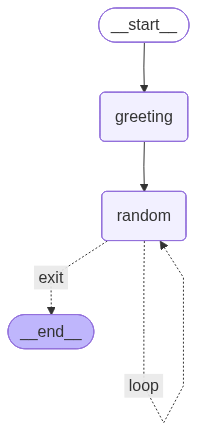

In [25]:
from IPython.display import Image, display

# Plot the graph as a PNG image
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Could not plot graph. Ensure you have internet connection for the Mermaid API.")


In [26]:
app.invoke({"name": "Babar", "number":[], "counter":-1})

Entering Loop 1
Entering Loop 2
Entering Loop 3
Entering Loop 4


{'name': 'Hi there, Babar', 'number': [0, 1, 10, 6, 8], 'counter': 5}

# Exercise for Graph v

![Image Description](task5.png)

 

- This exercise is asking you to build a number guessing game using a looping LangGraph workflow.
- The main learning objective is to understand how to create a loop in LangGraph: after each guess, the graph decides whether to end or go back and make another guess based on the hint and attempt count.

In [24]:
import random 
from typing import TypedDict, List, Literal

from langgraph.graph import StateGraph, START, END


In [44]:
class Game_State(TypedDict):

    player_name: str
    guesses: List[int]
    attempts: int
    lower_bound: int
    upper_bound: int
    max_guesses: int
    secret_number: int 


def setup_node(state: Game_State)-> Game_State:

    state["player_name"] = f"Welcome, {state['player_name']}!"
    state["secret_number"] = random.randint(1,20)
    state["guesses"] = []
    state["attempts"] = 0
    state['hint'] = "Game started! Try to guess the number."
    state["max_guesses"] = 7
    state["lower_bound"] = 1
    state["upper_bound"] = 20
    print(f"{state['player_name']} The game has begun. I'm thinking of a number between 1 and 20.")
    print(f"the secrate number is {state['secret_number']}")

    return state


def guess_node(state: Game_State)-> Game_State:

    current_guess = (state["lower_bound"] + state["upper_bound"]) // 2
    state['guesses'].append(current_guess)
    
    state["attempts"] += 1
    print(f"Attempt {state['attempts']}: Guessing {current_guess} (Current range: {state['lower_bound']}-{state['upper_bound']})")
   
    return state
    

def hint_node(state:Game_State)-> Game_State:

    latest_guess = state["guesses"][-1]

    if latest_guess > state["secret_number"]:
        state["hint"] = f"The number {latest_guess} is too high. Try lower!"
        state["upper_bound"] = state["secret_number"] - 1
    

    elif latest_guess < state["secret_number"]:
        state["hint"] = f"The number {latest_guess} is too low. Try higher!"
        state["lower_bound"] = state["secret_number"] + 1
        

    return state



def should_continue(state: Game_State):

    lastest_attempts = state["attempts"]
    latest_guess = state["guesses"][-1]

    if latest_guess == state["secret_number"]:
        state["hint"] = f"Correct! You found the number {latest_guess} in {state['attempts']} attempts."
        print(f"Success! {state['hint']}")
        return "end"
        
    if lastest_attempts >= state['max_guesses']:
        print(f"GAME OVER: Maximum attempts reached! The number was {state['target_number']}")
        return "end"

    elif lastest_attempts < state['max_guesses']:
        print(f"Continuing: {state['attempts']}/7 attempts used")
        return "continue"


In [45]:
workflow = StateGraph(Game_State)

workflow.add_node("setup",setup_node)
workflow.add_node("guess",guess_node)
workflow.add_node("hint",hint_node)

workflow.add_edge(START, 'setup')
workflow.add_edge('setup', 'guess')
workflow.add_edge('guess', 'hint')

workflow.add_conditional_edges(
    'hint',

    should_continue,
    {
        "continue": 'guess',
        'end': END,
    }
)

workflow.add_edge('hint', END)

app = workflow.compile()


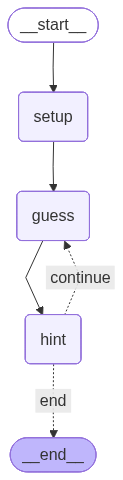

In [46]:
from IPython.display import Image, display

# Plot the graph as a PNG image
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Could not plot graph. Ensure you have internet connection for the Mermaid API.")


In [47]:
app.invoke({"player_name": "Babar Raheem"})

Welcome, Babar Raheem! The game has begun. I'm thinking of a number between 1 and 20.
the secrate number is 3
Attempt 1: Guessing 10 (Current range: 1-20)
Continuing: 1/7 attempts used
Attempt 2: Guessing 1 (Current range: 1-2)
Continuing: 2/7 attempts used
Attempt 3: Guessing 3 (Current range: 4-2)
Success! Correct! You found the number 3 in 3 attempts.


{'player_name': 'Welcome, Babar Raheem!',
 'guesses': [10, 1, 3],
 'attempts': 3,
 'lower_bound': 4,
 'upper_bound': 2,
 'max_guesses': 7,
 'secret_number': 3}